# **Setup**

## 1. Install and Import Libraries

Install and import all necessary libraries that will be used throughout this assignment.

In [1]:
!pip install kaggle dask polars matplotlib seaborn -q

In [1]:
import shutil
import pandas as pd
import numpy as np
import os
import time
import tracemalloc
import psutil
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from functools import wraps

## 2. Create Folder in Drive

Mount drive and create a folder to store the dataset.

In [3]:
os.makedirs("/content/drive/MyDrive/HPDP_A2", exist_ok=True)

# **Task 1: Dataset Selection**

This task involves selecting a dataset larger than 700 MB from a reliable public source.

**Dataset Details:**

*   Source: [Cell Towers Worldwide: Location Data by Continent](https://www.kaggle.com/datasets/zakariaeyoussefi/cell-towers-worldwide-location-data-by-continent)
*   Size: 1.56GB
*   Records: ~13.38 Million Rows
*   Domain: Telecommunications / Geospatial Analytics

## 1. Download Dataset using Kaggle API

Upload Kaggle API credentials to authenticate with Kaggle.

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fiqdanish","key":"4ae7b376d3462d663cdd1e9f79001718"}'}

Configure Kaggle API credentials in the correct directory.

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Download only the Asia towers CSV file from the dataset.

In [7]:
!kaggle datasets download \
    -d zakariaeyoussefi/cell-towers-worldwide-location-data-by-continent \
    -f "Asia towers.csv" \
    --force

Dataset URL: https://www.kaggle.com/datasets/zakariaeyoussefi/cell-towers-worldwide-location-data-by-continent
License(s): CC-BY-SA-4.0
100% 321M/321M [00:03<00:00, 95.7MB/s]



Unzip the downloaded ZIP file.

In [8]:
!unzip "Asia%20towers.csv.zip"

Archive:  Asia%20towers.csv.zip
  inflating: Asia towers.csv         


Verify the file exists and confirm its size meets the 700 MB requirement.

In [9]:
file_path = "Asia towers.csv"
size_bytes = os.path.getsize(file_path)
print(f"File: {file_path}")
print(f"Size: {size_bytes / (1024**2):.2f} MB  ({size_bytes / (1024**3):.3f} GB)")

File: Asia towers.csv
Size: 1489.43 MB  (1.455 GB)


## 2. Upload Dataset into Drive

Copy the downloaded dataset to Google Drive for persistent storage across sessions.

In [10]:
shutil.copy("Asia towers.csv", "/content/drive/MyDrive/HPDP_A2/Asia towers.csv")
print("Saved to Google Drive!✅")

Saved to Google Drive!✅


# **Task 2: Load and Inspect Data**

This task focuses on loading the dataset efficiently and performing an initial inspection to understand its structure before any processing begins. The inspection covers the dataset shape, column names and data types, missing values summary, and a preview of the first few rows.

## 1. Setting Up File Path

Define the file path pointing to the dataset stored in Google Drive.

In [2]:
file_path = "/content/drive/MyDrive/HPDP_A2/Asia towers.csv"

## 2. Load Dataset

Load the first 1 million rows of the dataset using Pandas for initial inspection.

In [12]:
df = pd.read_csv(file_path, nrows=1000000)

## 3. Inspect Dataset

Display the number of rows and columns in the dataset.

In [13]:
print("=== Dataset Shape ===")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

=== Dataset Shape ===
Rows    : 1,000,000
Columns : 18


Display all column names and their corresponding data types.

In [14]:
print("=== Column Names and Data Type ===")
print(df.dtypes.to_string())

=== Column Names and Data Type ===
Unnamed: 0         int64
radio             object
MCC                int64
MNC                int64
TAC                int64
CID                int64
unit               int64
LON              float64
LAT              float64
RANGE              int64
SAM                int64
changeable         int64
created            int64
updated            int64
averageSignal      int64
Country           object
Network           object
Continent         object


Identify columns with missing values.

In [15]:
print("=== Missing Values Summary ===")
missing = df.isnull().sum()
print(missing)

=== Missing Values Summary ===
Unnamed: 0       0
radio            0
MCC              0
MNC              0
TAC              0
CID              0
unit             0
LON              0
LAT              0
RANGE            0
SAM              0
changeable       0
created          0
updated          0
averageSignal    0
Country          0
Network          0
Continent        0
dtype: int64


Preview the first 5 rows to understand the structure of the data.

In [16]:
print("=== First 5 Rows Preview ===")
df.head()

=== First 5 Rows Preview ===


,Unnamed: 0,radio,MCC,MNC,TAC,CID,unit,LON,LAT,RANGE,SAM,changeable,created,updated,averageSignal,Country,Network,Continent
0,12142742,GSM,525,1,63,452,0,103.827896,1.431656,1000,3,1,1459692344,1487379337,0,Singapore,SingTel,Asia
1,12142743,UMTS,525,1,315,20666852,0,103.625793,1.309433,1000,2,1,1370464837,1370464837,0,Singapore,SingTel,Asia
2,12142744,GSM,525,1,63,5143,0,103.838882,1.425247,1000,3,1,1380831294,1461549037,0,Singapore,SingTel,Asia
3,12142745,GSM,525,1,63,5142,0,103.838775,1.416006,1000,192,1,1380831294,1483700507,0,Singapore,SingTel,Asia
4,12142746,GSM,525,1,63,5171,0,103.825607,1.426163,1000,1,1,1459671632,1459671632,0,Singapore,SingTel,Asia


# **Task 3: Big Data Handling Strategies**

This task applies five big data handling strategies to process the dataset efficiently. Each strategy is implemented using Pandas as the baseline, and where applicable, compared against Dask and Polars. Performance is measured using a custom `measure_performance` decorator that tracks execution time and memory usage.

## 1. Performance Measurement Function Setup

Define the performance results storage path and load any previously saved results from Drive.

In [3]:
RESULTS_PATH = "/content/drive/MyDrive/HPDP_A2/performance_results.csv"

# Load existing results from Drive if available
if os.path.exists(RESULTS_PATH):
    performance_results = pd.read_csv(RESULTS_PATH).to_dict('records')
    print(f"✅ Loaded {len(performance_results)} existing results from Drive!")
else:
    performance_results = []
    print("✅ Starting fresh performance results!")

✅ Loaded 13 existing results from Drive!


Define the `measure_performance` decorator to automatically track and record execution time and memory usage for every strategy function.

In [4]:
def measure_performance(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        process = psutil.Process(os.getpid())

        mem_before = process.memory_info().rss / 1024**2

        tracemalloc.start()
        start = time.time()
        result = func(*args, **kwargs)
        total_time = time.time() - start

        _, mem_peak_traced = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        mem_after = process.memory_info().rss / 1024**2
        mem_peak_traced  = mem_peak_traced / 1024**2

        mem_peak = mem_peak_traced if mem_peak_traced > 0 else mem_after

        # Calculate DataFrame memory usage if result is a DataFrame
        if isinstance(result, pd.DataFrame):
            df_mem = result.memory_usage(deep=True).sum() / 1024**2
        elif isinstance(result, pl.DataFrame):
            df_mem = result.estimated_size() / 1024**2
        elif isinstance(result, dd.DataFrame):
            df_mem = result.memory_usage(deep=True).sum().compute() / 1024**2
        else:
            df_mem = 0.0

        # Parse function name
        func_name = func.__name__
        if 'pandas' in func_name:
            library = 'Pandas'
        elif 'dask' in func_name:
            library = 'Dask'
        elif 'polars' in func_name:
            library = 'Polars'
        else:
            library = 'Unknown'

        if 'load_full' in func_name:
            strategy = 'Load Full Data'
        elif 'load_less' in func_name:
            strategy = 'Load Less Data'
        elif 'chunking' in func_name:
            strategy = 'Chunking'
        elif 'optimisation' in func_name:
            strategy = 'Data Type Optimisation'
        elif 'sampling' in func_name:
            strategy = 'Sampling'
        else:
            strategy = 'Unknown'

        # Auto-save to Drive after every run
        pd.DataFrame(performance_results).to_csv(RESULTS_PATH, index=False)
        print(f"💾 Results auto-saved to Drive! ({len(performance_results)} records)")

        # Store result
        performance_results.append({
            'Strategy'           : strategy,
            'Library'            : library,
            'Total Time (s)'     : round(total_time, 4),
            'Memory Before (MB)' : round(mem_before, 2),
            'Memory After (MB)'  : round(mem_after, 2),
            'Memory Peak (MB)'   : round(mem_peak, 2) if mem_peak is not None else 'N/A',
            'DataFrame Size (MB)': round(df_mem, 2)
        })

        report = pd.DataFrame([{
            'Function Name'       : func.__name__,
            'Total Time (s)'      : f"{total_time:.4f}",
            'Memory Before (MB)'  : f"{mem_before:.2f}",
            'Memory After (MB)'   : f"{mem_after:.2f}",
            'Memory Peak (MB)'    : f"{mem_peak:.2f}",
            'DataFrame Size (MB)' : f"{df_mem:.2f}"
        }])
        report.index = ['']
        print(f"\nPerformance Report: {func.__name__}")
        display(report)

        return result
    return wrapper

## 2. Strategy Operations

This section consists all of the strategy being used to handle the dataset.

### **Strategy 1: Load Less Data**

Read the first 5 rows of the dataset to see all available columns.

In [19]:
df_peek = pd.read_csv(file_path, nrows=5)
print("Available columns:")
print(list(df_peek.columns))

Available columns:
['Unnamed: 0', 'radio', 'MCC', 'MNC', 'TAC', 'CID', 'unit', 'LON', 'LAT', 'RANGE', 'SAM', 'changeable', 'created', 'updated', 'averageSignal', 'Country', 'Network', 'Continent']


Define the selected columns to load instead of reading the entire dataset.

In [5]:
SELECTED_COLS = ['radio', 'MCC', 'MNC', 'TAC', 'LON', 'LAT', 'RANGE', 'created', 'updated']

Load only the selected columns using the `usecols` parameter to reduce memory consumption.

In [21]:
@measure_performance
def load_less_data_pandas():
    return pd.read_csv(file_path, usecols=SELECTED_COLS, nrows=1000000)

df_less = load_less_data_pandas()

💾 Results auto-saved to Drive! (0 records)

Performance Report: load_less_data_pandas


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,load_less_data_pandas,2.1053,552.18,583.93,229.73,110.85


### **Strategy 2: Chunking**

Load the full dataset in chunks of 100,000 rows at a time using Pandas to avoid memory overload.

In [22]:
@measure_performance
def chunking_pandas():
    chunk_size = 100000
    chunks = []

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        chunks.append(chunk)

    df = pd.concat(chunks, ignore_index=True)
    return df

df_chunked = chunking_pandas()

💾 Results auto-saved to Drive! (1 records)

Performance Report: chunking_pandas


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,chunking_pandas,56.4329,584.66,4322.14,3675.78,4213.35


### **Strategy 3: Data Type Optimisation**

Load the dataset with default data types to establish a memory baseline before optimisation.

In [23]:
df_before = pd.read_csv(file_path, nrows=1000000)

print("\n=== Data Types Before Optimisation ===")
print(df_before.dtypes.to_string())


=== Data Types Before Optimisation ===
Unnamed: 0         int64
radio             object
MCC                int64
MNC                int64
TAC                int64
CID                int64
unit               int64
LON              float64
LAT              float64
RANGE              int64
SAM                int64
changeable         int64
created            int64
updated            int64
averageSignal      int64
Country           object
Network           object
Continent         object


Define optimised data types for each column to reduce memory footprint.

In [13]:
OPTIMISED_DTYPES = {
    'Unnamed: 0'   : 'int32',    # Row index — fits in int32
    'radio'        : 'category', # Repeated strings e.g. GSM, LTE, UMTS
    'MCC'          : 'int16',    # Mobile country code — small integer
    'MNC'          : 'int16',    # Mobile network code — small integer
    'TAC'          : 'int16',    # Tracking area code — fits in int16
    'CID'          : 'int32',    # Cell ID — fits in int32
    'unit'         : 'int16',    # Small integer
    'LON'          : 'float32',  # Longitude — float32 sufficient
    'LAT'          : 'float32',  # Latitude — float32 sufficient
    'RANGE'        : 'int16',    # Range in metres — fits in int16
    'SAM'          : 'int16',    # Sample count — fits in int16
    'changeable'   : 'int8',     # Binary-like flag — int8 sufficient
    'created'      : 'int32',    # Timestamp — fits in int32
    'updated'      : 'int32',    # Timestamp — fits in int32
    'averageSignal': 'int16',    # Signal strength — small integer
    'Country'      : 'category', # Repeated country names
    'Network'      : 'category', # Repeated network names
    'Continent'    : 'category', # Repeated continent names
}

Load the dataset with optimised data types applied using Pandas.

In [25]:
@measure_performance
def data_type_optimisation_pandas():
    df = pd.read_csv(
        file_path,
        dtype=OPTIMISED_DTYPES,
        nrows=1000000
    )
    return df

df_optimised = data_type_optimisation_pandas()

print("\n=== Data Types After Optimisation ===")
print(df_optimised.dtypes.to_string())

💾 Results auto-saved to Drive! (2 records)

Performance Report: data_type_optimisation_pandas


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,data_type_optimisation_pandas,19.0760,3156.06,3158.67,436.78,41.01



=== Data Types After Optimisation ===
Unnamed: 0          int32
radio            category
MCC                 int16
MNC                 int16
TAC                 int16
CID                 int32
unit                int16
LON               float32
LAT               float32
RANGE               int16
SAM                 int16
changeable           int8
created             int32
updated             int32
averageSignal       int16
Country          category
Network          category
Continent        category


### **Strategy 4: Sampling**

Load a random 10% sample of the dataset using Pandas.

In [26]:
@measure_performance
def sampling_pandas():
    df = pd.read_csv(file_path, low_memory=False)
    df_sample = df.sample(frac=0.1, random_state=42)
    return df_sample

df_sampled = sampling_pandas()
print(f"Shape: {df_sampled.shape}")

💾 Results auto-saved to Drive! (3 records)

Performance Report: sampling_pandas


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,sampling_pandas,65.9153,3158.71,3101.89,6123.15,431.68


Shape: (1337599, 18)


Perform quick exploratory analysis on the sampled dataset.

In [27]:
print("=== 1. Sample Distribution by Radio Type ===")
display(df_sampled['radio'].value_counts().to_frame())

print("\n=== 2. Sample Distribution by Country (Top 10) ===")
display(df_sampled['Country'].value_counts().head(10).to_frame())

print("\n=== 3. Average Signal Strength by Radio Type ===")
display(df_sampled.groupby('radio')['averageSignal'].mean().to_frame())

print("\n=== 4. Basic Statistics ===")
display(df_sampled.describe())

=== 1. Sample Distribution by Radio Type ===


,count
radio,
UMTS,570180
LTE,510574
GSM,254178
NR,2087
CDMA,580



=== 2. Sample Distribution by Country (Top 10) ===


,count
Country,
Japan,231891
Russia,210277
Indonesia,140408
Thailand,127602
China,103996
South Korea,87580
Malaysia,58774
Taiwan,48401
Iran,44851



=== 3. Average Signal Strength by Radio Type ===


,averageSignal
radio,
CDMA,0.0
GSM,0.0
LTE,0.0
NR,0.0
UMTS,0.0



=== 4. Basic Statistics ===


,Unnamed: 0,MCC,MNC,TAC,CID,unit,LON,LAT,RANGE,SAM,changeable,created,updated,averageSignal
count,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1.337599e+06,1337599.0,1.337599e+06,1.337599e+06,1337599.0
mean,2.846186e+07,4.314660e+02,1.641148e+01,2.000876e+04,7.614718e+07,5.559573e+00,9.646386e+01,2.752541e+01,1.651073e+03,1.284433e+01,1.0,1.493966e+09,1.510060e+09,0.0
std,1.136582e+07,8.518755e+01,2.660688e+01,1.478956e+05,1.019166e+09,4.218756e+01,3.536044e+01,1.811284e+01,5.130541e+03,7.030275e+01,0.0,8.236199e+07,8.667735e+07,0.0
min,1.214275e+07,2.500000e+02,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-8.371651e+01,-1.079613e+01,3.280000e+02,1.000000e+00,1.0,9.466675e+08,9.466675e+08,0.0
25%,1.750235e+07,4.240000e+02,2.000000e+00,4.106000e+03,1.321334e+06,0.000000e+00,5.974846e+01,1.437198e+01,1.000000e+03,1.000000e+00,1.0,1.453243e+09,1.457946e+09,0.0
50%,2.887690e+07,4.500000e+02,6.000000e+00,1.047200e+04,2.304769e+07,0.000000e+00,1.059216e+02,3.171135e+01,1.000000e+03,2.000000e+00,1.0,1.469839e+09,1.489424e+09,0.0
75%,3.923190e+07,5.020000e+02,1.600000e+01,2.791900e+04,7.251559e+07,0.000000e+00,1.237850e+02,3.694008e+01,1.000000e+03,9.000000e+00,1.0,1.505512e+09,1.506393e+09,0.0
max,4.628056e+07,5.280000e+02,2.990000e+02,1.677721e+07,5.964970e+10,5.110000e+02,1.777413e+02,7.260630e+01,2.280287e+06,3.048800e+04,1.0,1.715274e+09,1.715299e+09,0.0


### **Strategy 5: Parallel Processing with Dask and Polars**

Perform the same strategy used by Pandas previously with Dask and Polars.

**1. Load Full Data**

Pandas:

Load the full dataset using Pandas to establish the implementation baseline.

In [28]:
@measure_performance
def load_full_data_pandas():
    df = pd.read_csv(file_path, low_memory=False)
    return df

df_pandas_full = load_full_data_pandas()
print(f"Shape: {df_pandas_full.shape}")

💾 Results auto-saved to Drive! (4 records)

Performance Report: load_full_data_pandas


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,load_full_data_pandas,57.9719,3028.10,4833.57,6123.15,4214.69


Shape: (13375989, 18)


Dask:

Load the full dataset using Dask which automatically distributes the workload across multiple CPU cores.

In [29]:
@measure_performance
def load_full_data_dask():
    df = dd.read_csv(file_path, assume_missing=True, low_memory=False)
    df = df.compute()
    return df

df_dask_full = load_full_data_dask()
print(f"Shape: {df_dask_full.shape}")

💾 Results auto-saved to Drive! (5 records)

Performance Report: load_full_data_dask


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,load_full_data_dask,57.0755,4835.22,8288.27,3062.78,2224.70


Shape: (13375989, 18)


Polars:

Load the full dataset using Polars which natively utilises all available CPU cores for parallel processing.

In [5]:
@measure_performance
def load_full_data_polars():
    df = pl.read_csv(file_path)
    return df

df_polars_full = load_full_data_polars()
print(f"Shape: {df_polars_full.shape}")

💾 Results auto-saved to Drive! (13 records)

Performance Report: load_full_data_polars


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,load_full_data_polars,47.2004,288.07,4060.03,0.01,1714.45


Shape: (13375989, 18)


**2. Load Less Data**

Dask:

Load only the selected columns using the `usecols` parameter using Dask.

In [6]:
@measure_performance
def load_less_data_dask():
    df = dd.read_csv(file_path, usecols=SELECTED_COLS, assume_missing=True, low_memory=False)
    df = df.compute()
    return df

df_dask_less = load_less_data_dask()
print(f"Shape: {df_dask_less.shape}")

💾 Results auto-saved to Drive! (6 records)

Performance Report: load_less_data_dask


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,load_less_data_dask,54.7907,288.14,2388.70,1837.78,1064.20


Shape: (13375989, 9)


Polars:

Load only the selected columns using the `columns` parameter using Polars.

In [7]:
@measure_performance
def load_less_data_polars():
    df = pl.read_csv(file_path, columns=SELECTED_COLS)
    return df

df_polars_less = load_less_data_polars()
print(f"Shape: {df_polars_less.shape}")

💾 Results auto-saved to Drive! (7 records)

Performance Report: load_less_data_polars


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,load_less_data_polars,8.2624,2389.52,4911.07,0.01,860.10


Shape: (13375989, 9)


**3. Chunking**

Dask:

Load the full dataset using Dask with automatic partitioning of 10MB per partition.

In [8]:
@measure_performance
def chunking_dask():
    df = dd.read_csv(file_path, assume_missing=True, low_memory=False, blocksize=10e6)  # 10MB per partition
    df = df.compute()
    return df

df_dask_chunked = chunking_dask()

💾 Results auto-saved to Drive! (8 records)

Performance Report: chunking_dask


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,chunking_dask,47.3624,3422.06,6368.11,3067.64,2224.70


Polars:

Load the full dataset using Polars with automatic batching of 100,000 rows at a time.

In [9]:
@measure_performance
def chunking_polars():
    df = pl.read_csv(file_path, batch_size=100_000)
    return df

df_polars_chunked = chunking_polars()

💾 Results auto-saved to Drive! (9 records)

Performance Report: chunking_polars


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,chunking_polars,13.3918,6368.11,9463.74,0.00,1714.45


**4. Sampling**

Dask:

Load and sample 10% of the dataset using Dask.

In [10]:
@measure_performance
def sampling_dask():
    df = dd.read_csv(file_path, assume_missing=True, low_memory=False)
    df_sample = df.sample(frac=0.1, random_state=42)
    df_sample = df_sample.compute()
    return df_sample

df_dask_sampled = sampling_dask()
print(f"Shape: {df_dask_sampled.shape}")

💾 Results auto-saved to Drive! (10 records)

Performance Report: sampling_dask


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,sampling_dask,45.2316,8639.61,8816.62,900.06,223.11


Shape: (1337599, 18)


Polars:

Load and sample 10% of the dataset using Polars.

In [11]:
@measure_performance
def sampling_polars():
    df = pl.read_csv(file_path)
    df_sample = df.sample(fraction=0.1, seed=42)
    return df_sample

df_polars_sampled = sampling_polars()
print(f"Shape: {df_polars_sampled.shape}")

💾 Results auto-saved to Drive! (11 records)

Performance Report: sampling_polars


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,sampling_polars,24.0326,8810.86,11326.18,0.00,171.44


Shape: (1337598, 18)


**5. Data Type Optimisation**

Dask:

Load the dataset with optimised data types applied using Dask.

In [15]:
@measure_performance
def data_type_optimisation_dask():
    df = dd.read_csv(file_path, assume_missing=True, low_memory=False, dtype=OPTIMISED_DTYPES)
    df = df.head(1000000, compute=True)
    return df

df_dask_optimised = data_type_optimisation_dask()
print("\n=== Data Types After Optimisation ===")
print(df_dask_optimised.dtypes.to_string())

💾 Results auto-saved to Drive! (12 records)

Performance Report: data_type_optimisation_dask


/usr/local/lib/python3.12/dist-packages/dask/dataframe/core.py:382: UserWarning: Insufficient elements for `head`. 1000000 elements requested, only 538915 elements available. Try passing larger `npartitions` to `head`.
  warnings.warn(


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,data_type_optimisation_dask,8.8978,11334.42,10906.72,364.89,22.10



=== Data Types After Optimisation ===
Unnamed: 0          int32
radio            category
MCC                 int16
MNC                 int16
TAC                 int16
CID                 int32
unit                int16
LON               float32
LAT               float32
RANGE               int16
SAM                 int16
changeable           int8
created             int32
updated             int32
averageSignal       int16
Country          category
Network          category
Continent        category


Polars:

Define Polars-equivalent optimised data types using the Polars type system.

In [8]:
POLARS_OPTIMISED_DTYPES = {
    'Unnamed: 0'   : pl.Int32,
    'radio'        : pl.Categorical,
    'MCC'          : pl.Int16,
    'MNC'          : pl.Int16,
    'TAC'          : pl.Int32,
    'CID'          : pl.Int64,
    'unit'         : pl.Int16,
    'LON'          : pl.Float32,
    'LAT'          : pl.Float32,
    'RANGE'        : pl.Int32,
    'SAM'          : pl.Int32,
    'changeable'   : pl.Int8,
    'created'      : pl.Int32,
    'updated'      : pl.Int32,
    'averageSignal': pl.Int16,
    'Country'      : pl.Categorical,
    'Network'      : pl.Categorical,
    'Continent'    : pl.Categorical,
}

Load the dataset with optimised data types applied using Polars.

In [9]:
@measure_performance
def data_type_optimisation_polars():
    df = pl.read_csv(file_path, schema_overrides=POLARS_OPTIMISED_DTYPES)
    df = df.slice(0, 1000000)
    return df

df_polars_optimised = data_type_optimisation_polars()
print("\n=== Data Types After Optimisation ===")
print(df_polars_optimised.dtypes)

💾 Results auto-saved to Drive! (14 records)

Performance Report: data_type_optimisation_polars


,Function Name,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
,data_type_optimisation_polars,15.5614,2573.31,4085.79,0.00,61.99



=== Data Types After Optimisation ===
[Int32, Categorical, Int16, Int16, Int32, Int64, Int16, Float32, Float32, Int32, Int32, Int8, Int32, Int32, Int16, Categorical, Categorical, Categorical]


# **Task 4: Comparative Analysis**

This section compares the performance of Pandas, Dask and Polars across all strategies using three key metrics:  

*   Execution time
*   Memory Peak
*   DataFrame Size

Results are presented in comparison tables grouped by metric and visualised in a bar chart.

## 1. Load Saved Results

Load all previously saved performance results from Google Drive into a DataFrame.

In [10]:
df_performance = pd.DataFrame(performance_results)
display(df_performance)

,Strategy,Library,Total Time (s),Memory Before (MB),Memory After (MB),Memory Peak (MB),DataFrame Size (MB)
0,Load Less Data,Pandas,2.1053,552.18,583.93,229.73,110.85
1,Chunking,Pandas,56.4329,584.66,4322.14,3675.78,4213.35
2,Data Type Optimisation,Pandas,19.0760,3156.06,3158.67,436.78,41.01
3,Sampling,Pandas,65.9153,3158.71,3101.89,6123.15,431.68
4,Load Full Data,Pandas,57.9719,3028.10,4833.57,6123.15,4214.69
5,Load Full Data,Dask,57.0755,4835.22,8288.27,3062.78,2224.70
6,Load Less Data,Dask,54.7907,288.14,2388.70,1837.78,1064.20
7,Load Less Data,Polars,8.2624,2389.52,4911.07,0.01,860.10
8,Chunking,Dask,47.3624,3422.06,6368.11,3067.64,2224.70
9,Chunking,Polars,13.3918,6368.11,9463.74,0.00,1714.45


## 2. Comparison Table

Display comparison tables grouped by each performance metric with libraries as columns.

In [11]:
metrics = ['Total Time (s)', 'Memory Peak (MB)', 'DataFrame Size (MB)']

for metric in metrics:
    print(f"\n=== {metric} ===")

    # Pivot table: rows = Strategy, columns = Library
    df_pivot = df_performance.pivot_table(
        index='Strategy',
        columns='Library',
        values=metric,
        aggfunc='first'
    ).reset_index()

    # Reorder columns
    df_pivot.columns.name = None
    df_pivot = df_pivot[['Strategy', 'Pandas', 'Dask', 'Polars']]

    display(df_pivot)


=== Total Time (s) ===


,Strategy,Pandas,Dask,Polars
0,Chunking,56.4329,47.3624,13.3918
1,Data Type Optimisation,19.0760,8.8978,15.5614
2,Load Full Data,57.9719,57.0755,47.2004
3,Load Less Data,2.1053,54.7907,8.2624
4,Sampling,65.9153,45.2316,24.0326



=== Memory Peak (MB) ===


,Strategy,Pandas,Dask,Polars
0,Chunking,3675.78,3067.64,0.00
1,Data Type Optimisation,436.78,364.89,0.00
2,Load Full Data,6123.15,3062.78,0.01
3,Load Less Data,229.73,1837.78,0.01
4,Sampling,6123.15,900.06,0.00



=== DataFrame Size (MB) ===


,Strategy,Pandas,Dask,Polars
0,Chunking,4213.35,2224.70,1714.45
1,Data Type Optimisation,41.01,22.10,61.99
2,Load Full Data,4214.69,2224.70,1714.45
3,Load Less Data,110.85,1064.20,860.10
4,Sampling,431.68,223.11,171.44


Generate a bar chart comparing average performance across all strategies for each library.

/tmp/ipykernel_384/2566542021.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_avg['Library'], rotation=15)
/tmp/ipykernel_384/2566542021.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_avg['Library'], rotation=15)
/tmp/ipykernel_384/2566542021.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_avg['Library'], rotation=15)


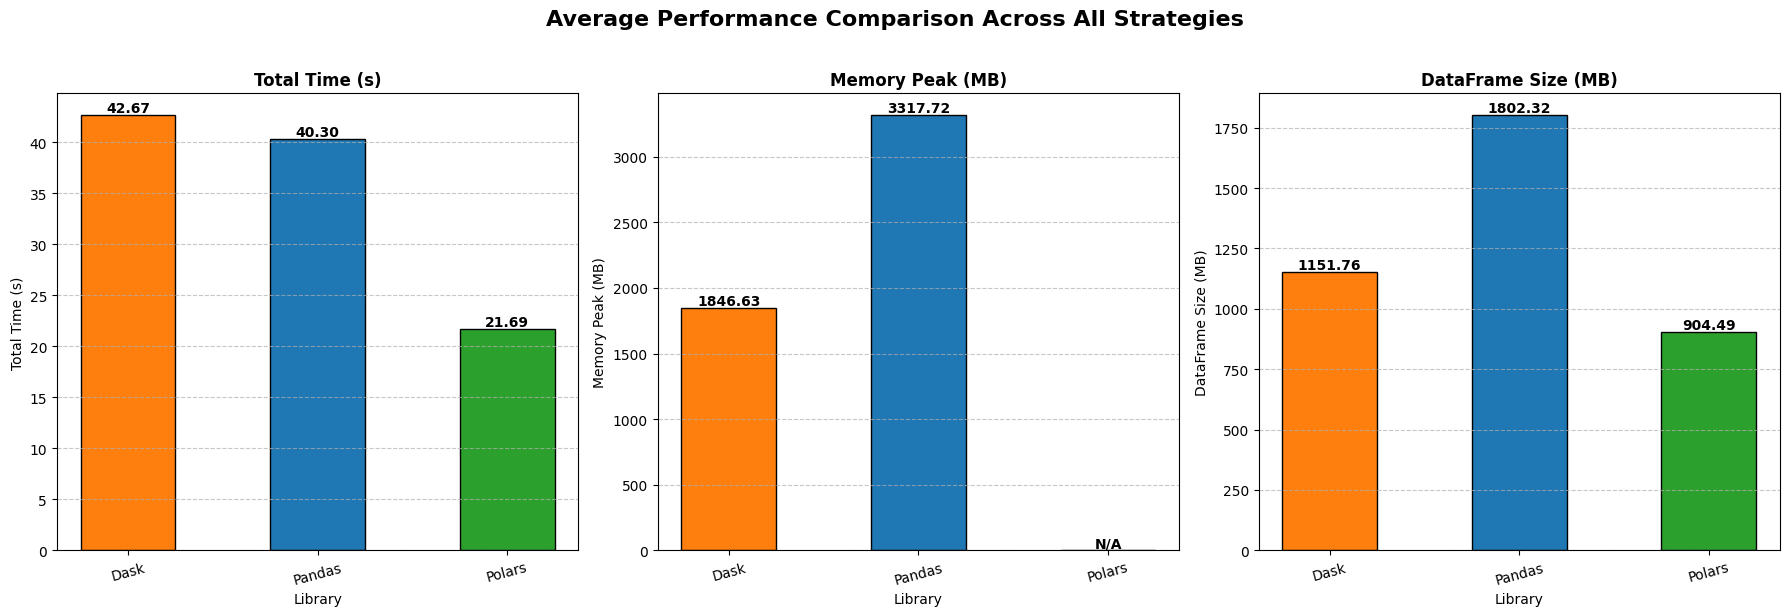

✅ Chart saved to Drive!


In [12]:
metrics = ['Total Time (s)', 'Memory Peak (MB)', 'DataFrame Size (MB)']
libraries = ['Pandas', 'Dask', 'Polars']
colors = {'Pandas': '#1f77b4', 'Dask': '#ff7f0e', 'Polars': '#2ca02c'}

# Convert metrics to numeric, replace N/A with 0
df_plot = df_performance.copy()
for metric in metrics:
    df_plot[metric] = pd.to_numeric(df_plot[metric], errors='coerce').fillna(0)

# Calculate average for each library across all strategies
df_avg = df_plot.groupby('Library')[metrics].mean().reset_index()

# Plot 1x3 grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Average Performance Comparison Across All Strategies',
             fontsize=16, fontweight='bold', y=1.02)

for ax, metric in zip(axes, metrics):
    bar_colors = [colors[lib] for lib in df_avg['Library']]
    bars = ax.bar(df_avg['Library'], df_avg[metric], color=bar_colors,
                  edgecolor='black', width=0.5)

    # Add value labels on top of bars
    for bar, lib in zip(bars, df_avg['Library']):
        height = bar.get_height()
        label = f'{height:.2f}' if not (metric == 'Memory Peak (MB)' and lib == 'Polars') else 'N/A'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label,
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Library', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_xticklabels(df_avg['Library'], rotation=15)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/HPDP_A2/average_performance_comparison.png",
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved to Drive!")